In [69]:
# install Lib
#%pip install chembl_webresource_client

In [70]:
#Load Libraries 
from rdkit import Chem
from rdkit.Chem import Descriptors, QED, rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams
from rdkit import DataStructs
from rdkit.DataStructs import BulkTanimotoSimilarity # much faster for bulk comparisons
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import seaborn as sns
from chembl_webresource_client.new_client import new_client
from multiprocessing import Pool, cpu_count # for parallel processing we can try later 

In [71]:
import torch

# check Metal GPU is available for PyTorch if on Mac with M1/M2 chip and PyTorch 2.0+
print(torch.backends.mps.is_available())  # should print True

True


In [72]:
# Step 1 — load candidates
url        = "https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/models/zinc_properties/250k_rndm_zinc_drugs_clean_3.csv"
df         = pd.read_csv(url)
candidates = df["smiles"].tolist()[:100000]
print(f"Candidates: {len(candidates)}")

# Step 2 — load ChEMBL reference
activity      = new_client.activity
acts          = activity.filter(
                    target_chembl_id="CHEMBL1781",
                    standard_type="IC50"
                ).only("canonical_smiles")
chembl_smiles = [a["canonical_smiles"] for a in acts if a["canonical_smiles"]]
print(f"Reference: {len(chembl_smiles)}")

# Step 3 — fingerprint generator
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def encode(smi):
    mol = Chem.MolFromSmiles(smi.strip())
    if mol is None: return None
    return gen.GetFingerprint(mol)

# Step 4 — encode reference once
ref_fps = [fp for fp in [encode(s) for s in chembl_smiles] if fp is not None]
print(f"Valid reference fps: {len(ref_fps)}")

# Step 5 — encode all candidates in bulk first
print("Encoding candidates...")
candidate_fps = [(smi, encode(smi)) for smi in candidates]
candidate_fps = [(smi, fp) for smi, fp in candidate_fps if fp is not None]
print(f"Valid candidates: {len(candidate_fps)}")

# Step 6 — score in batches using numpy for max speed
print("Scoring...")
BATCH = 1000
results = []

for i in range(0, len(candidate_fps), BATCH):
    batch = candidate_fps[i:i+BATCH]
    for smi, fp in batch:
        scores = BulkTanimotoSimilarity(fp, ref_fps)
        results.append({"smiles": smi, "tanimoto": max(scores)})
    print(f"  processed {min(i+BATCH, len(candidate_fps))}/{len(candidate_fps)}")

df_results = pd.DataFrame(results)
hits       = df_results[df_results["tanimoto"] > 0.60].copy()
print(f"Scored: {len(df_results)}  Hits >0.60: {len(hits)}")

Candidates: 100000
Reference: 735
Valid reference fps: 735
Encoding candidates...
Valid candidates: 100000
Scoring...
  processed 1000/100000
  processed 2000/100000
  processed 3000/100000
  processed 4000/100000
  processed 5000/100000
  processed 6000/100000
  processed 7000/100000
  processed 8000/100000
  processed 9000/100000
  processed 10000/100000
  processed 11000/100000
  processed 12000/100000
  processed 13000/100000
  processed 14000/100000
  processed 15000/100000
  processed 16000/100000
  processed 17000/100000
  processed 18000/100000
  processed 19000/100000
  processed 20000/100000
  processed 21000/100000
  processed 22000/100000
  processed 23000/100000
  processed 24000/100000
  processed 25000/100000
  processed 26000/100000
  processed 27000/100000
  processed 28000/100000
  processed 29000/100000
  processed 30000/100000
  processed 31000/100000
  processed 32000/100000
  processed 33000/100000
  processed 34000/100000
  processed 35000/100000
  processed 3600

In [73]:
# feature extraction for candidates
candidate_fps = []
for smi in candidates:
    fp = encode(smi)
    if fp is not None:
        candidate_fps.append(fp)
print(f"Valid candidate fingerprints: {len(candidate_fps)}")


Valid candidate fingerprints: 100000


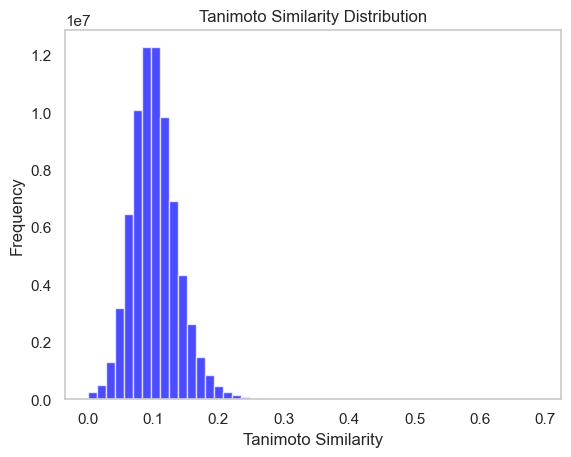

In [74]:
#plot similarity distribution
similarities = []
for c_fp in candidate_fps:
    for r_fp in ref_fps:
        sim = DataStructs.TanimotoSimilarity(c_fp, r_fp)
        similarities.append(sim)
plt.hist(similarities, bins=50, color='blue', alpha=0.7)
plt.title('Tanimoto Similarity Distribution')
plt.xlabel('Tanimoto Similarity')
plt.ylabel('Frequency')
plt.grid()
plt.show()


In [75]:
# STEP 5: Score all candidates 
results = []
for smi in candidates:
    fp = encode(smi)
    if fp is None: continue
    scores = [DataStructs.TanimotoSimilarity(fp, r) for r in ref_fps]
    results.append({"smiles": smi, "tanimoto": max(scores)})

df_results = pd.DataFrame(results)
print(f"\nAll candidates scored: {len(df_results)}")
print(df_results["tanimoto"].describe())

# STEP 6: Filter to statin-like hits (>0.40) 
hits = df_results[df_results["tanimoto"] > 0.40].copy()
print(f"\nCandidates passing Tanimoto >0.40: {len(hits)}")
# STEP 7: Filter to drug-like hits (Tanimoto > 0.6)
drug_like = df_results[df_results["tanimoto"] > 0.6].copy()
print(f"\nCandidates passing Tanimoto >0.6: {len(drug_like)}")  
drug_like = df_results[df_results["tanimoto"] > 0.7].copy()
print(f"\nCandidates passing Tanimoto >0.7: {len(drug_like)}")  


All candidates scored: 100000
count    100000.000000
mean          0.224507
std           0.055829
min           0.064935
25%           0.187500
50%           0.217949
75%           0.253731
max           0.689655
Name: tanimoto, dtype: float64

Candidates passing Tanimoto >0.40: 891

Candidates passing Tanimoto >0.6: 9

Candidates passing Tanimoto >0.7: 0


['smiles', 'tanimoto', 'mw', 'logp', 'hbd', 'hba', 'qed', 'violations']


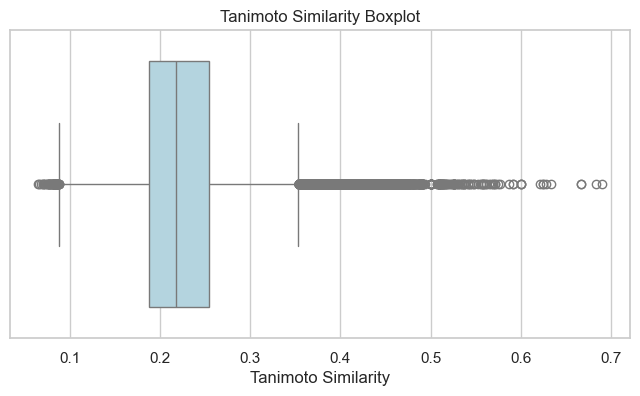

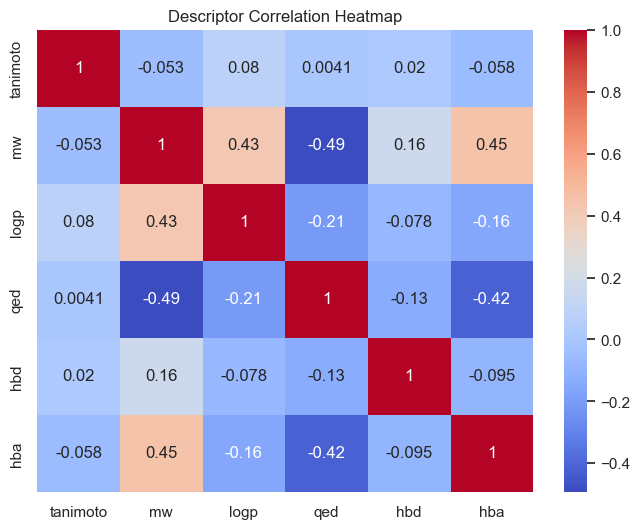

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

# compute descriptors on hits
def get_descriptors(smi):
    mol = Chem.MolFromSmiles(smi.strip())
    if mol is None: return None
    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd  = rdMolDescriptors.CalcNumHBD(mol)
    hba  = rdMolDescriptors.CalcNumHBA(mol)
    qed  = QED.qed(mol)
    viol = sum([mw > 500, logp > 5, hbd > 5, hba > 10])
    return {
        "mw": round(mw,2), "logp": round(logp,2),
        "hbd": hbd, "hba": hba,
        "qed": round(qed,3), "violations": viol
    }

hits["desc"] = hits["smiles"].apply(get_descriptors)
hits         = pd.concat([hits, hits["desc"].apply(pd.Series)], axis=1)
hits         = hits.drop(columns=["desc"])
print(hits.columns.tolist())

sns.set(style="whitegrid")

# Plot 1 — Tanimoto boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_results["tanimoto"], color="lightblue")
plt.title("Tanimoto Similarity Boxplot")
plt.xlabel("Tanimoto Similarity")
plt.show()

# Plot 2 — Descriptor correlation heatmap (hits only)
plt.figure(figsize=(8, 6))
sns.heatmap(
    hits[["tanimoto","mw","logp","qed","hbd","hba"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Descriptor Correlation Heatmap")
plt.show()

<Axes: xlabel='group', ylabel='tanimoto'>

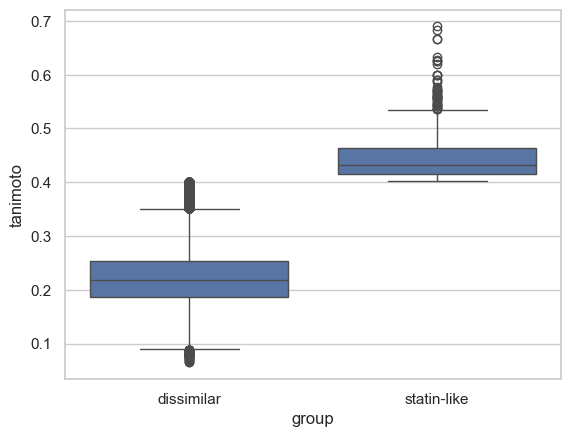

In [77]:
#hits vs all candidates
df_results["group"] = df_results["tanimoto"].apply(
    lambda x: "statin-like" if x > 0.40 else "dissimilar"
)
sns.boxplot(data=df_results, x="group", y="tanimoto")

In [78]:
# STEP 7: Drug-likeness descriptors on hits
def get_descriptors(smi):
    mol = Chem.MolFromSmiles(smi.strip())
    if mol is None: return None
    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd  = rdMolDescriptors.CalcNumHBD(mol)
    hba  = rdMolDescriptors.CalcNumHBA(mol)
    qed  = QED.qed(mol)
    viol = sum([mw > 500, logp > 5, hbd > 5, hba > 10])
    return {
        "mw":         round(mw,   2),
        "logp":       round(logp, 2),
        "hbd":        hbd,
        "hba":        hba,
        "qed":        round(qed,  3),
        "violations": viol
    }

#STEP 8: PAINS filter on hits 
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
pains  = FilterCatalog(params)

def has_pains(smi):
    mol = Chem.MolFromSmiles(smi.strip())
    if mol is None: return True
    return pains.GetFirstMatch(mol) is not None

hits["desc"]       = hits["smiles"].apply(get_descriptors)
hits               = pd.concat([hits, hits["desc"].apply(pd.Series)], axis=1)
hits               = hits.drop(columns=["desc"])
hits["pains_flag"] = hits["smiles"].apply(has_pains)

# STEP 9: Summary
print("\nDescriptor summary of hits:")
print(hits[["tanimoto","mw","logp","qed","violations"]].describe())

passed_lipinski = (hits["violations"] == 0).sum()
pains_flagged   = hits["pains_flag"].sum()
clean           = ((hits["violations"] == 0) & (~hits["pains_flag"])).sum()

print(f"\nPassed Lipinski (0 violations): {passed_lipinski}")
print(f"PAINS flagged:                  {pains_flagged}")
print(f"Clean candidates:               {clean}")

print("\nAll hits:")
print(hits[["smiles","tanimoto","mw","logp","qed","violations","pains_flag"]])



Descriptor summary of hits:
         tanimoto          mw          mw        logp        logp         qed  \
count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000   
mean     0.446311  341.254220  341.254220    3.416756    3.416756    0.727521   
std      0.044354   53.529694   53.529694    1.067713    1.067713    0.145001   
min      0.402439  150.180000  150.180000   -1.960000   -1.960000    0.224000   
25%      0.414634  309.265000  309.265000    2.790000    2.790000    0.636000   
50%      0.431818  339.360000  339.360000    3.480000    3.480000    0.758000   
75%      0.462963  373.455000  373.455000    4.185000    4.185000    0.842000   
max      0.689655  498.460000  498.460000    6.480000    6.480000    0.946000   

              qed  violations  violations  
count  891.000000  891.000000  891.000000  
mean     0.727521    0.038159    0.038159  
std      0.145001    0.191688    0.191688  
min      0.224000    0.000000    0.000000  
25%      0.636000    

ValueError: cannot reindex on an axis with duplicate labels

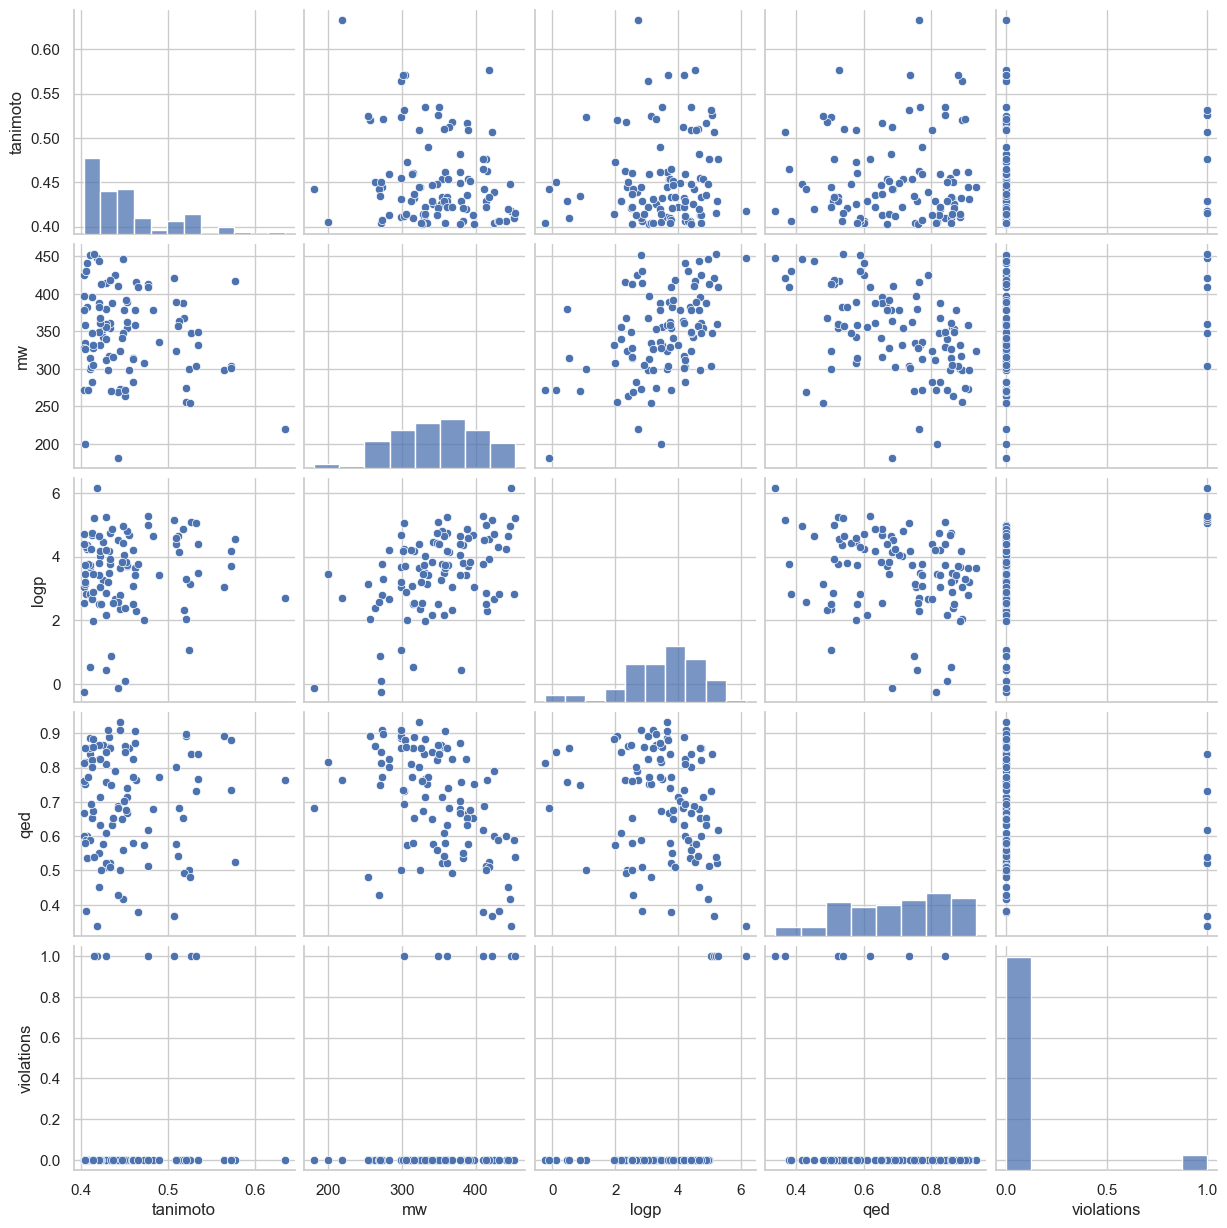

In [ ]:
#pairplot
sns.pairplot(
    hits[["tanimoto","mw","logp","qed","violations"]],
    diag_kind="hist"
)

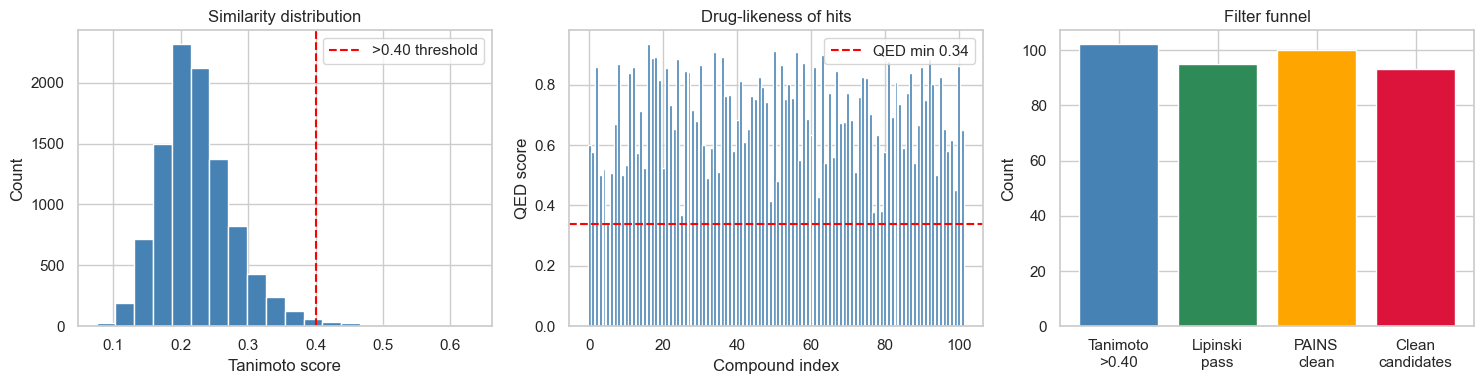

In [ ]:
# STEP 10: Visualisations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 — Tanimoto distribution
axes[0].hist(df_results["tanimoto"], bins=20, color="steelblue", edgecolor="white")
axes[0].axvline(0.40, color="red",    linestyle="--", label=">0.40 threshold")
axes[0].set_xlabel("Tanimoto score")
axes[0].set_ylabel("Count")
axes[0].set_title("Similarity distribution")
axes[0].legend()

# Plot 2 — QED distribution of hits
if len(hits) > 0:
    axes[1].bar(range(len(hits)), hits["qed"], color="steelblue", edgecolor="white")
    axes[1].axhline(0.34, color="red", linestyle="--", label="QED min 0.34")
    axes[1].set_xlabel("Compound index")
    axes[1].set_ylabel("QED score")
    axes[1].set_title("Drug-likeness of hits")
    axes[1].legend()

# Plot 3 — Filter summary
labels  = ["Tanimoto\n>0.40", "Lipinski\npass", "PAINS\nclean", "Clean\ncandidates"]
values  = [len(hits), passed_lipinski, len(hits)-pains_flagged, clean]
colors  = ["steelblue", "seagreen", "orange", "crimson"]
axes[2].bar(labels, values, color=colors, edgecolor="white")
axes[2].set_ylabel("Count")
axes[2].set_title("Filter funnel")

plt.tight_layout()
plt.show()


In [79]:
# Score ChEMBL compounds against the 7 named statins
known_statins = [
    ("Atorvastatin",  "CC(C)c1c(C(=O)Nc2ccccc2F)c(-c2ccccc2F)c(-c2ccc(F)cc2)n1CCC(O)CC(O)CC(=O)O"),
    ("Simvastatin",   "CCC(C)(C)C(=O)OC1CC(O)CC(=O)O1"),
    ("Rosuvastatin",  "CC(C)c1nc(N(C)S(=O)(=O)C)nc(c2ccc(F)cc2)c1/C=C/[C@@H](O)C[C@@H](O)CC(=O)O"),
    ("Fluvastatin",   "OC(=O)C[C@@H](O)C[C@@H](O)/C=C/c1c(C2CC2)nc2ccccc12"),
    ("Pravastatin",   "OC(=O)[C@@H](O)C[C@@H](O)CC(=O)O"),
    ("Lovastatin",    "CCC(C)C(=O)O[C@@H]1C[C@@H](O)CC(=O)O1"),
    ("Pitavastatin",  "OC(=O)C[C@@H](O)C[C@@H](O)/C=C/c1nc2ccccc2c1-c1ccc2ccccc2c1"),
]

statin_fps = [(name, encode(smi)) for name, smi in known_statins]
statin_fps = [(name, fp) for name, fp in statin_fps if fp is not None]

scores = []
for smi in chembl_smiles:
    fp = encode(smi)
    if fp is None: continue
    best = max(BulkTanimotoSimilarity(fp, [sfp for _, sfp in statin_fps]))
    scores.append(best)

import pandas as pd
s = pd.Series(scores)
print(s.describe())
print(f"Statin-like >0.70: {(s > 0.70).sum()}")
print(f"Statin-like >0.60: {(s > 0.60).sum()}")
print(f"Statin-like >0.40: {(s > 0.40).sum()}")

count    735.000000
mean       0.134672
std        0.028868
min        0.056180
25%        0.112500
50%        0.138889
75%        0.155844
max        0.232558
dtype: float64
Statin-like >0.70: 0
Statin-like >0.60: 0
Statin-like >0.40: 0


[16:51:50] Can't kekulize mol.  Unkekulized atoms: 11 12 16 17 18 19 20 21 22
[16:51:50] Can't kekulize mol.  Unkekulized atoms: 11 12 13 14 15 16 17 18 19
